# Download co-located NEON AOP and EMIT data and convolve

End-to-end tutorial using real acquisitions over Niwot Ridge (NIWO), Colorado — a subalpine/alpine ecotone site operated by NEON.

**Instruments**

| | EMIT | NEON AOP |
|---|---|---|
| Platform | ISS (spaceborne) | Airborne (Twin Otter) |
| Sensor | AVIRIS-NG derivative | CASI-derived / custom |
| Bands | 288 good, 366–2500 nm | ~426, 383–2512 nm |
| FWHM | 8.4–8.8 nm (nominal) | ~5–6 nm (per-tile from file) |
| Pixel size | 60 m | 1 m |
| Collection | EMITL2ARFL v001 @ LP DAAC | DP3.30006.002 @ NEON Data Portal |

**What we do**
1. Find overlapping NEON and EMIT granules with `srfforge.search.find_overlapping`
2. Download a 1 km² NEON AOP reflectance tile via `neonutilities`
3. Read the HDF5 file with `srfforge.io.read_neon_h5` (includes new spatial metadata)
4. Convolve from NEON ~5 nm sampling to EMIT ~8.6 nm sampling with `BandConvolver`
5. Visualize with `srfforge.plot`

---
## 1. Setup

### Option A — conda (recommended)
Creates an isolated environment with all dependencies pre-solved:
```bash
# from the srfforge repo root
conda env create -f environment.yml
conda activate srfforge
```

### Option B — pip into an existing environment
```bash
# from the srfforge repo root
pip install -e ".[full,dev]"
```
`[full]` installs: `earthaccess`, `neonutilities`, `shapely`, `pyproj`, `matplotlib`

> **Why conda for this tutorial?** `pyproj` and `shapely` have C extensions that can
> be tricky to build with pip on some platforms. `conda-forge` ships pre-built binaries.

### NASA Earthdata account
1. Register (free) at https://urs.earthdata.nasa.gov/users/new
2. Run the login cell once — credentials are saved to `~/.netrc` for future sessions.

### NEON Data Portal
NEON data is open-access. `neonutilities.by_tile_aop` downloads directly — no account needed.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import glob

import earthaccess
import neonutilities as nu

from srfforge import BandConvolver, EMIT, NEON
from srfforge.io import read_neon_h5
from srfforge.search import find_overlapping
from srfforge.plot import compare_spectra, rgb_quicklook, plot_residuals

In [7]:
# persist=True saves credentials to ~/.netrc so you only need to do this once
auth = earthaccess.login(persist=True)
print("Authenticated:", auth.authenticated)

Authenticated: True


---
## 2. Find co-located NEON and EMIT data

`find_overlapping` does three things under the hood:
1. Calls `neonutilities.get_aop_tile_extents` to get the UTM footprints of all NEON tiles flown at the site that year
2. Converts tile footprints from UTM → WGS84 via `pyproj`
3. Searches EMIT via `earthaccess` using the bounding box, then pairs each tile with every overlapping EMIT granule

**`site` and `year` both accept single values or collections:**

```python
# Single site, single year (used below)
find_overlapping(site="NIWO", year=2023)

# Multiple sites
find_overlapping(site=["NIWO", "HARV"], year=2023)

# Inclusive year range — (start, end) tuple
find_overlapping(site="NIWO", year=(2021, 2023))  # searches 2021, 2022, 2023

# Explicit year list — only the years you specify
find_overlapping(site="NIWO", year=[2021, 2023])  # skips 2022
```

In [42]:
# Niwot Ridge, Colorado — alpine site, UTM zone 13N
pairs = find_overlapping(site="NIWO", year=2023, max_cloud=30)

print(f"Found {len(pairs)} NEON tile / EMIT granule pairs\n")
for p in pairs[:5]:
    print(
        f"  NEON tile  ({p.neon.easting:>7d}, {p.neon.northing:>8d})  "
        f"UTM {p.neon.utm_zone}N"
    )
    print(
        f"  EMIT       {p.emit.granule_id}  "
        f"{p.emit.datetime.date()}  cloud={p.emit.cloud_cover:.0f}%"
    )
    print()

Easting Bounds: (443000, 458000)
Northing Bounds: (4422000, 4438000)
Granules found: 13


Found 2651 NEON tile / EMIT granule pairs

  NEON tile  ( 443000,  4436000)  UTM 13N
  EMIT       EMIT_L2A_RFL_001_20230203T185001_2303413_010  2023-02-03  cloud=0%

  NEON tile  ( 443000,  4436000)  UTM 13N
  EMIT       EMIT_L2A_RFL_001_20230329T212754_2308814_017  2023-03-29  cloud=0%

  NEON tile  ( 443000,  4436000)  UTM 13N
  EMIT       EMIT_L2A_RFL_001_20230329T212806_2308814_018  2023-03-29  cloud=0%

  NEON tile  ( 443000,  4436000)  UTM 13N
  EMIT       EMIT_L2A_RFL_001_20230402T195326_2309213_018  2023-04-02  cloud=0%

  NEON tile  ( 443000,  4436000)  UTM 13N
  EMIT       EMIT_L2A_RFL_001_20230406T181842_2309612_019  2023-04-06  cloud=0%



/opt/miniconda3/envs/srfforge/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [43]:
# Pick the first pair (best available after cloud filter)
chosen = pairs[0]

print("Chosen NEON tile:")
print(f"  site     : {chosen.neon.site}")
print(f"  year     : {chosen.neon.year}")
print(f"  easting  : {chosen.neon.easting}")
print(f"  northing : {chosen.neon.northing}")
print(f"  UTM zone : {chosen.neon.utm_zone}N")
print(f"  lat/lon  : {chosen.neon.bbox_latlon}")
print()
print("Matched EMIT granule:")
print(f"  id       : {chosen.emit.granule_id}")
print(f"  date     : {chosen.emit.datetime.date()}")
print(f"  cloud    : {chosen.emit.cloud_cover:.0f}%")
print(f"  lat/lon  : {chosen.emit.bbox_latlon}")

Chosen NEON tile:
  site     : NIWO
  year     : 2023
  easting  : 443000
  northing : 4436000
  UTM zone : 13N
  lat/lon  : (-105.66846570019872, 40.07233675821649, -105.65682551959908, 40.081412921409665)

Matched EMIT granule:
  id       : EMIT_L2A_RFL_001_20230203T185001_2303413_010
  date     : 2023-02-03
  cloud    : 0%
  lat/lon  : (-106.29222106933594, 39.43177795410156, -104.92146301269531, 40.69195556640625)


In [ ]:
# Browse available tiles before committing to a download.
# NEON flights don't always cover the full site footprint,
# and some tiles are cloud-masked. Tiles near the center of
# the flight box tend to have better coverage.

unique_tiles = list({(p.neon.easting, p.neon.northing) for p in pairs})
unique_tiles.sort()
print(f"{len(unique_tiles)} unique NEON tiles available:\n")
for e, n in unique_tiles:
    print(f"  easting={e:>7d}  northing={n:>8d}")

---
## 3. Download the NEON AOP tile

`neonutilities.by_tile_aop` downloads a single 1 km² tile by easting/northing.
Files land in `data/DP3.30006.002/NIWO/<year>/`. The reflectance HDF5 is ~200–500 MB.

Data product DP3.30006.002 = bidirectional surface reflectance (includes BRDF and topographic correction).

> **Provisional data:** recent NEON collections (typically the last 1–2 years) are
> marked provisional until quality-reviewed. Pass `include_provisional=True` to
> download them — this is required for any data from roughly 2023 onward.

In [44]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# chosen.neon picks pairs[0] which may be an edge tile with little valid data.
# Pick a tile near the NIWO core site (easting ~454000, northing ~4431000)
# or inspect the unique_tiles list above and choose one near the center of the range.
EASTING  = 454000
NORTHING = 4431000

nu.by_tile_aop(
    dpid="DP3.30006.002",
    site=chosen.neon.site,
    year=chosen.neon.year,
    easting=EASTING,
    northing=NORTHING,
    savepath=str(data_dir),
    include_provisional=True,
)

h5_files = sorted(data_dir.rglob("*reflectance*.h5"))
print("Downloaded H5 files:")
for f in h5_files:
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.0f} MB)")

Provisional NEON data are included. To exclude provisional data, use input parameter include_provisional=False.

100%|██████████| 2/2 [00:20<00:00, 10.37s/it]


Downloaded H5 files:
  NEON_D13_NIWO_DP3_443000_4436000_bidirectional_reflectance.h5  (55 MB)
  NEON_D13_NIWO_DP3_454000_4431000_bidirectional_reflectance.h5  (738 MB)


---
## 4. Read the NEON HDF5 file

`read_neon_h5` returns:
- `refl` — `(rows, cols, n_bands)` float32, scaled 0–1
- `neon` — `NEON` instrument object with per-band wavelengths and FWHM
- `meta` — dict with `site`, `scale_factor`, bad-band windows, **and now `utm_bounds` + `epsg`**

NEON AOP tiles are 1000 × 1000 pixels at 1 m resolution. Each band in the H5 is stored as `int16` and divided by `Scale_Factor` (typically 10 000) to give 0–1 reflectance.

In [45]:
import h5py
from pathlib import Path

h5_path = sorted(Path("data").rglob("*reflectance*.h5"))[0]
print(f"Inspecting: {h5_path.name}\n")

with h5py.File(h5_path, "r") as f:
    site = next(iter(f.keys()))
    refl_ds = f[site]["Reflectance"]["Reflectance_Data"]

    print(f"dtype  : {refl_ds.dtype}")
    print(f"shape  : {refl_ds.shape}")
    print()
    print("Attributes on Reflectance_Data:")
    for k, v in refl_ds.attrs.items():
        print(f"  {k!r:35s} = {v!r}")
    print()
    sample = refl_ds[500:510, 500:510, 0]
    print("Raw sample values (row 500-510, col 500-510, band 0):")
    print(sample)

Inspecting: NEON_D13_NIWO_DP3_443000_4436000_bidirectional_reflectance.h5

dtype  : int16
shape  : (1000, 1000, 426)

Attributes on Reflectance_Data:
  'BRDF Correction'                   = 'True'
  'Cloud_conditions'                  = 'For cloud conditions information see Weather Quality Index dataset.'
  'Cloud_type'                        = 'Cloud type may have been selected from multiple flight trajectories.'
  'Data_Ignore_Value'                 = np.int32(-9999)
  'Description'                       = 'Atmospherically corrected reflectance.'
  'Dimension_Labels'                  = 'Line, Sample, Wavelength'
  'Dimensions'                        = array([1000, 1000,  426])
  'Interleave'                        = 'BSQ'
  'Scale_Factor'                      = np.float64(10000.0)
  'Spatial_Extent_meters'             = array([ 443000.,  444000., 4436000., 4437000.])
  'Spatial_Resolution_X_Y'            = array([1., 1.])
  'Units'                             = 'Unitless.'
  'Units_V

In [46]:
h5_path = h5_files[1]

refl, neon, meta = read_neon_h5(h5_path)

print(f"Shape        : {refl.shape}  (rows, cols, bands)")
print(f"Bands        : {len(neon.wavelengths)}  ({neon.wavelengths[0]:.1f}–{neon.wavelengths[-1]:.1f} nm)")
print(f"FWHM range   : {neon.fwhm.min():.2f}–{neon.fwhm.max():.2f} nm")
print(f"Site         : {meta['site']}")
print(f"Scale factor : {meta['scale_factor']}")
print(f"EPSG         : {meta.get('epsg', 'n/a')}")
if 'utm_bounds' in meta:
    b = meta['utm_bounds']
    print(f"UTM bounds   : x {b['x_min']:.0f}–{b['x_max']:.0f}  y {b['y_min']:.0f}–{b['y_max']:.0f}  zone {b['utm_zone']}")
print(neon)

Shape        : (1000, 1000, 426)  (rows, cols, bands)
Bands        : 426  (381.9–2511.3 nm)
FWHM range   : 5.60–6.30 nm
Site         : NIWO
Scale factor : 10000.0
EPSG         : 32613
UTM bounds   : x 454000–455000  y 4431000–4432000  zone 13
NEON(n_bands=426, range=381.9–2511.3 nm)


In [47]:
valid_frac = np.isfinite(refl[:, :, 0]).mean()
print(f"Valid pixels : {valid_frac:.1%}  of the tile")

Valid pixels : 100.0%  of the tile


---
## 5. Convolve to EMIT spectral sampling

NEON AOP has finer spectral resolution (~5 nm FWHM) than EMIT (~8.6 nm FWHM).
`BandConvolver` builds a `(n_EMIT, n_NEON)` Gaussian weight matrix — each EMIT band
is a weighted average of nearby NEON bands, with weights given by the EMIT Gaussian SRF.

The convolution is a single matrix multiply: `refl @ M.T`, applied over the full
1000 × 1000 tile in one shot.

In [48]:
emit = EMIT()   # bundled nominal wavelengths (288 bands)
print(emit)

conv = BandConvolver(source=neon, target=emit)
print(f"Convolution matrix: {conv.matrix.shape}  (EMIT bands × NEON bands)")

refl_emit = conv(refl)
print(f"\nNEON original  : {refl.shape}")
print(f"Convolved      : {refl_emit.shape}")

EMIT(n_bands=288, range=366.0–2500.2 nm)
Convolution matrix: (288, 426)  (EMIT bands × NEON bands)

NEON original  : (1000, 1000, 426)
Convolved      : (1000, 1000, 288)


---
## 6. Visualize

### 6a. Spectrum comparison

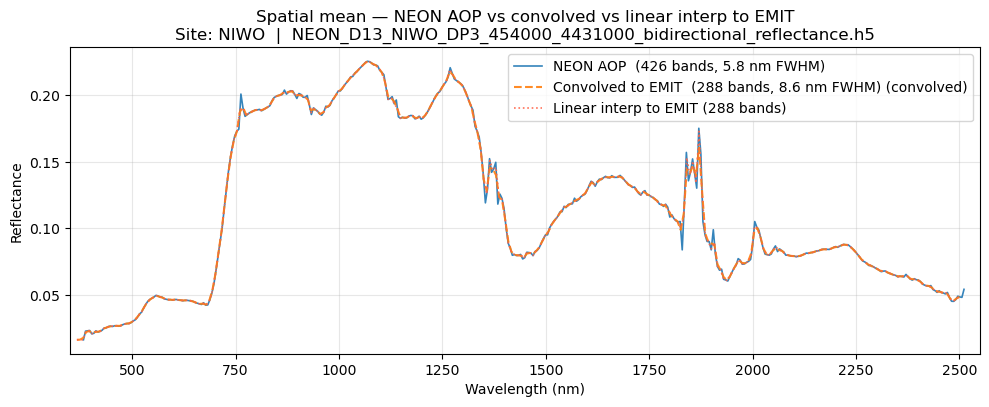

Saved: neon_emit_spectrum_comparison.png


In [49]:
fig = compare_spectra(
    source_refl=refl,
    target_refl=refl_emit,
    source=neon,
    target=emit,
    n_sample=500,
    source_label=f"NEON AOP  ({len(neon.wavelengths)} bands, {neon.fwhm.mean():.1f} nm FWHM)",
    target_label=f"Convolved to EMIT  ({len(emit.wavelengths)} bands, {emit.fwhm.mean():.1f} nm FWHM)",
)

# Add linear interpolation line using the same pixel sample as compare_spectra (seed=0)
src_flat = refl.reshape(-1, refl.shape[-1])
valid_idx = np.where(np.isfinite(src_flat).all(axis=1))[0]
idx = np.random.default_rng(seed=0).choice(valid_idx, size=min(500, len(valid_idx)), replace=False)
src_mean = src_flat[idx].mean(axis=0)
emit_interp = np.interp(emit.wavelengths, neon.wavelengths, src_mean)

ax = fig.axes[0]
ax.plot(emit.wavelengths, emit_interp, lw=1.2, ls=":", color="tomato",
        label=f"Linear interp to EMIT ({len(emit.wavelengths)} bands)", alpha=0.9)
ax.legend()
ax.set_xlim(350, 2550)
ax.set_title(
    f"Spatial mean — NEON AOP vs convolved vs linear interp to EMIT\n"
    f"Site: {meta['site']}  |  {h5_path.name}"
)
fig.savefig(data_dir / "neon_emit_spectrum_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: neon_emit_spectrum_comparison.png")

### 6b. RGB quicklooks

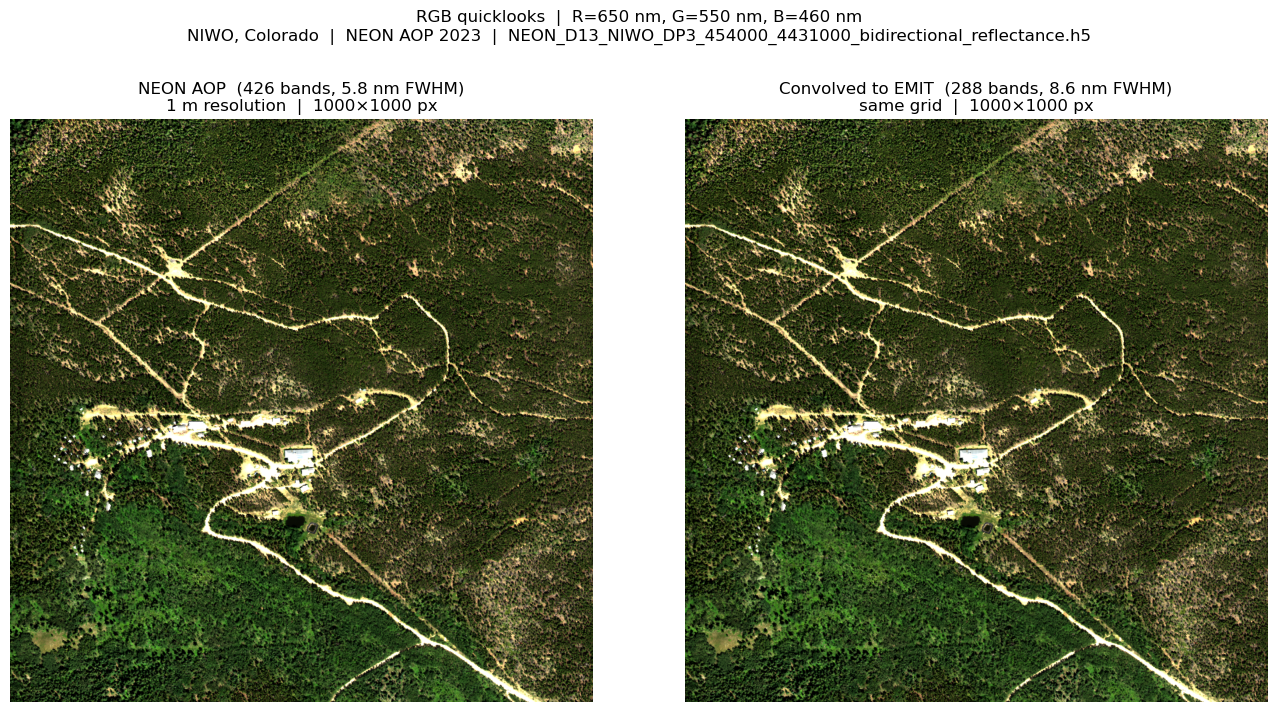

Saved: neon_emit_rgb_quicklooks.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rgb_quicklook(refl,      instrument=neon, ax=axes[0])
rgb_quicklook(refl_emit, instrument=emit, ax=axes[1])

axes[0].set_title(
    f"NEON AOP  ({refl.shape[2]} bands, {neon.fwhm.mean():.1f} nm FWHM)\n"
    f"1 m resolution  |  {refl.shape[0]}×{refl.shape[1]} px"
)
axes[1].set_title(
    f"Convolved to EMIT  ({refl_emit.shape[2]} bands, {emit.fwhm.mean():.1f} nm FWHM)\n"
    f"same grid  |  {refl_emit.shape[0]}×{refl_emit.shape[1]} px"
)
fig.suptitle(
    f"RGB quicklooks  |  R=650 nm, G=550 nm, B=460 nm\n"
    f"NIWO, Colorado  |  NEON AOP {chosen.neon.year}  |  {h5_path.name}",
    y=1.01,
)
fig.tight_layout()
fig.savefig(data_dir / "neon_emit_rgb_quicklooks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: neon_emit_rgb_quicklooks.png")

### 6c. SRF convolution vs linear interpolation

NEON has finer resolution (~5 nm) than EMIT (~8.6 nm), so the convolution genuinely
smooths the spectrum. `plot_residuals` shows where **SRF convolution differs from naive
linear interpolation** onto EMIT band centers. Largest differences are at steep spectral
gradients: O₂-A band (~760 nm), water vapour absorption edges (~1340 nm, ~1800 nm).

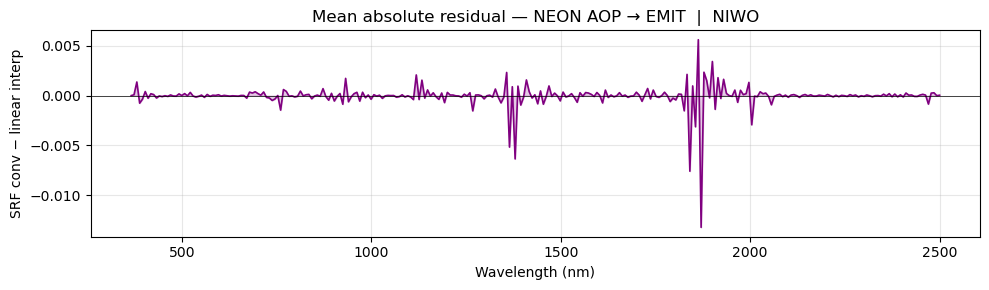

Saved: neon_emit_residuals.png


In [51]:
fig = plot_residuals(
    source_refl=refl,
    target_refl=refl_emit,
    source=neon,
    target=emit,
    n_sample=500,
)
fig.axes[0].set_title(
    f"Mean absolute residual — NEON AOP → EMIT  |  {meta['site']}"
)
fig.savefig(data_dir / "neon_emit_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: neon_emit_residuals.png")

### 6d. FWHM comparison

Unlike AVIRIS-3 (~8 nm) vs EMIT (~8.6 nm), NEON is genuinely finer-sampled (~5 nm)
so the convolution has real spectral smoothing work to do.

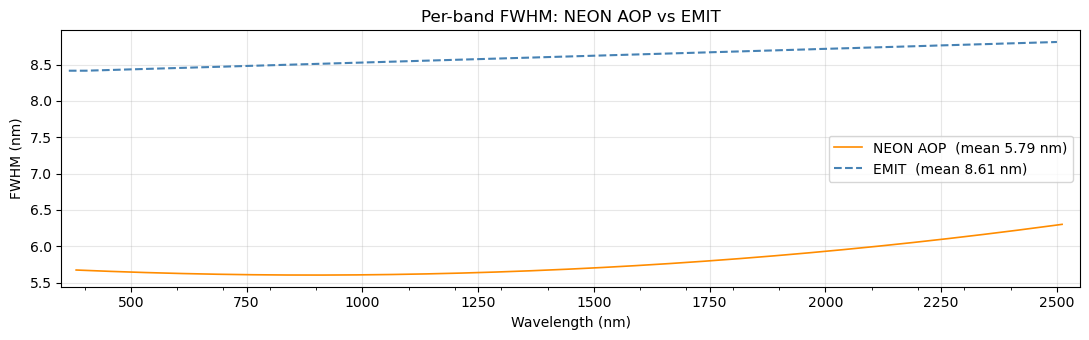

Saved: neon_emit_fwhm_comparison.png


In [52]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(neon.wavelengths, neon.fwhm, lw=1.2, color="darkorange",
        label=f"NEON AOP  (mean {neon.fwhm.mean():.2f} nm)")
ax.plot(emit.wavelengths, emit.fwhm, lw=1.5, ls="--", color="steelblue",
        label=f"EMIT  (mean {emit.fwhm.mean():.2f} nm)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("FWHM (nm)")
ax.set_title("Per-band FWHM: NEON AOP vs EMIT")
ax.legend()
ax.set_xlim(350, 2550)
ax.grid(True, alpha=0.3)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
fig.tight_layout()
fig.savefig(data_dir / "neon_emit_fwhm_comparison.png", dpi=150)
plt.show()
print("Saved: neon_emit_fwhm_comparison.png")

---
## 7. Save convolved reflectance

Save the convolved array as NetCDF4 (HDF5-backed, compressed) with EMIT wavelengths
embedded, preserving the NEON tile origin metadata.

In [56]:
import h5py

tile_tag = f"{chosen.neon.site}_{chosen.neon.easting}_{chosen.neon.northing}_{chosen.neon.year}"
nc_out = data_dir / f"{tile_tag}_convolved_to_EMIT.nc"

with h5py.File(nc_out, "w") as f:
    f.attrs["source_site"]     = chosen.neon.site
    f.attrs["source_tile"]     = f"{chosen.neon.easting},{chosen.neon.northing}"
    f.attrs["source_year"]     = chosen.neon.year
    f.attrs["source_dpid"]     = "DP3.30006.002"
    f.attrs["target_instrument"] = "EMIT"
    f.attrs["convolution"]     = "Gaussian SRF (srfforge BandConvolver)"
    if "epsg" in meta:
        f.attrs["source_epsg"] = meta["epsg"]

    grp = f.create_group("reflectance")

    ds = grp.create_dataset(
        "reflectance",
        data=refl_emit.astype(np.float32),
        compression="gzip", compression_opts=4,
    )
    ds.attrs["_FillValue"] = np.float32(np.nan)
    ds.attrs["long_name"]  = "Surface reflectance convolved to EMIT spectral sampling"
    ds.attrs["units"]      = "unitless"

    wl_ds = grp.create_dataset("wavelengths", data=emit.wavelengths.astype(np.float32))
    wl_ds.attrs["units"]     = "nm"
    wl_ds.attrs["long_name"] = "EMIT band centre wavelengths (nominal)"

    fw_ds = grp.create_dataset("fwhm", data=emit.fwhm.astype(np.float32))
    fw_ds.attrs["units"]     = "nm"
    fw_ds.attrs["long_name"] = "EMIT FWHM per band (nominal)"

    if "utm_bounds" in meta:
        b = meta["utm_bounds"]
        for k, v in b.items():
            if v is not None:
                grp.attrs[f"utm_{k}"] = v

print(f"Saved: {nc_out.name}  ({nc_out.stat().st_size / 1e6:.0f} MB)")

Saved: NIWO_443000_4436000_2023_convolved_to_EMIT.nc  (1021 MB)


In [57]:
print("All outputs:")
for f in sorted(data_dir.glob("*.png")) + sorted(data_dir.glob("*.nc")):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

All outputs:
  neon_emit_fwhm_comparison.png  (0.0 MB)
  neon_emit_residuals.png  (0.1 MB)
  neon_emit_rgb_quicklooks.png  (3.9 MB)
  neon_emit_spectrum_comparison.png  (0.1 MB)
  residual_comparison.png  (0.1 MB)
  rgb_quicklooks.png  (1.7 MB)
  spectrum_comparison.png  (0.1 MB)
  AV320240905t182728_000_L2A_OE_f576f24d_RFL_ORT.nc  (885.6 MB)
  AV320240905t182728_000_convolved_to_EMIT.nc  (1196.5 MB)
  NIWO_443000_4436000_2023_convolved_to_EMIT.nc  (1020.6 MB)
